<a href="https://colab.research.google.com/github/tmedeirosb/tsi-ad-2025/blob/main/MODULO_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# exibir todas as colunas
pd.set_option('display.max_columns', None)

url = "https://raw.githubusercontent.com/tmedeirosb/tsi-ad-2025/refs/heads/main/dados/dados_workflow_ivan.csv"
df = pd.read_csv(url)

display(df.head())

,LnguaPortuguesaeLiteraturaI90H,LnguaPortuguesaeLiteraturaI90H_dependencia,LnguaPortuguesaeLiteraturaI90H_freq,MatemticaI120H,MatemticaI120H_dependencia,MatemticaI120H_freq,aluno_exclusivo_rede_publica,descricao,descricao_area_residencial,descricao_companhia_domiciliar,descricao_estado_civil,descricao_historico,descricao_imovel,descricao_mae_escolaridade,descricao_pai_escolaridade,descricao_raca,descricao_responsavel_escolaridade,descricao_responsavel_financeiro,descricao_trabalho,id,idade,pessoa_fisica__sexo,possui_necessidade_especial,qnt_pc,qtd_pessoas_domicilio,sigla,tempo_entre_conclusao_ingresso,qnt_salarios,artificial,classe,conceito,conceito_freq,acompanhamento
0,68.0,0,100.0,66.0,0,100.0,False,Matriculado,Urbana,Mãe,Solteiro(a),Técnico de Nivel Médio em Informática,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Branca,Ensino fundamental incompleto,Mãe,Não informado,457884597605,15,F,False,0,2,LAJ,1,1,0,1,B,A,0
1,73.0,1,100.0,36.0,1,91.0,False,Cancelado,Urbana,Mãe,Solteiro(a),Técnico de Nível Médio em Meio Ambiente,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Parda,Ensino fundamental incompleto,Mãe,Não informado,458436647741,17,M,False,1,2,SPP,2,1,1,0,R,R,0
2,61.0,0,100.0,60.0,0,100.0,False,Matriculado,Urbana,Pais,Solteiro(a),Técnico de Nivel Médio em Informática,Alugado,Ensino médio completo,Ensino médio completo,Parda,Ensino médio completo,Mãe,Não informado,464029640533,15,M,True,0,5,CANG,2,2,0,1,B,A,0
3,NaN,-1,NaN,NaN,-1,NaN,False,Matriculado,Urbana,Pais,Solteiro(a),Técnico de Nível Médio em Mecânica,Alugado,Alfabetizado,Não estudou,Parda,Ensino fundamental incompleto,Mãe,Não está trabalhando,556372572373,16,F,False,1,5,MO,3,2,0,1,S,S,0
4,69.0,0,100.0,63.0,0,100.0,False,Matriculado,Urbana,Mãe,Solteiro(a),Técnico de Nivel Médio Informática,Alugado,Ensino fundamental incompleto,Ensino fundamental incompleto,Preta,Ensino fundamental incompleto,Mãe,Não está trabalhando,457614148801,15,F,False,0,3,PAR,1,1,0,1,R,A,2


In [2]:
df_sel = df[['LnguaPortuguesaeLiteraturaI90H', 'MatemticaI120H', 'descricao_responsavel_escolaridade', 'idade', 'descricao_raca', 'pessoa_fisica__sexo']]
df_sel

,LnguaPortuguesaeLiteraturaI90H,MatemticaI120H,descricao_responsavel_escolaridade,idade,descricao_raca,pessoa_fisica__sexo
0,68.0,66.0,Ensino fundamental incompleto,15,Branca,F
1,73.0,36.0,Ensino fundamental incompleto,17,Parda,M
2,61.0,60.0,Ensino médio completo,15,Parda,M
3,NaN,NaN,Ensino fundamental incompleto,16,Parda,F
4,69.0,63.0,Ensino fundamental incompleto,15,Preta,F
...,...,...,...,...,...,...
8903,29.0,11.0,Ensino fundamental incompleto,15,Amarela,M
8904,86.0,71.0,Ensino fundamental incompleto,15,Branca,F
8905,61.0,67.0,Ensino fundamental incompleto,15,Parda,F
8906,93.0,78.0,Ensino fundamental incompleto,14,Parda,F


## Pré-processamento de Dados

### 1. Separação de dados categóricos e numéricos

In [3]:
# 1. Separar dados categóricos e numéricos
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Identificar colunas numéricas e categóricas
colunas_numericas = df_sel.select_dtypes(include=[np.number]).columns.tolist()
colunas_categoricas = df_sel.select_dtypes(exclude=[np.number]).columns.tolist()

print("Colunas numéricas:", colunas_numericas)
print("Colunas categóricas:", colunas_categoricas)

Colunas numéricas: ['LnguaPortuguesaeLiteraturaI90H', 'MatemticaI120H', 'idade']
Colunas categóricas: ['descricao_responsavel_escolaridade', 'descricao_raca', 'pessoa_fisica__sexo']


### 2. Pré-processamento de dados numéricos (imputação pela mediana e escalonamento MinMax)

In [4]:
# 2. Processar dados numéricos
df_numericos = df_sel[colunas_numericas].copy()

# Imputação pela média
imputer_num = SimpleImputer(strategy='median')
df_numericos_imputados = imputer_num.fit_transform(df_numericos)

# Escalonamento MinMax
scaler = MinMaxScaler()
df_numericos_escalados = scaler.fit_transform(df_numericos_imputados)

# Criar DataFrame com os dados processados
df_numericos_processados = pd.DataFrame(df_numericos_escalados, columns=colunas_numericas)
print("Dados numéricos processados:")
df_numericos_processados.head()

Dados numéricos processados:


,LnguaPortuguesaeLiteraturaI90H,MatemticaI120H,idade
0,0.68,0.66,0.263158
1,0.73,0.36,0.298246
2,0.61,0.60,0.263158
3,0.72,0.65,0.280702
4,0.69,0.63,0.263158


### 3. Pré-processamento de dados categóricos (imputação pela moda e OneHotEncoder com drop_first)

In [5]:
# 3. Processar dados categóricos
df_categoricos = df_sel[colunas_categoricas].copy()

# Imputação pela moda
imputer_cat = SimpleImputer(strategy='most_frequent')
df_categoricos_imputados = imputer_cat.fit_transform(df_categoricos)

# OneHotEncoder com drop_first
encoder = OneHotEncoder(drop='first', sparse_output=False)
df_categoricos_encoded = encoder.fit_transform(df_categoricos_imputados)

# Criar DataFrame com os dados processados
feature_names = encoder.get_feature_names_out(colunas_categoricas)
df_categoricos_processados = pd.DataFrame(df_categoricos_encoded, columns=feature_names)
print("Dados categóricos processados:")
df_categoricos_processados.head()

Dados categóricos processados:


,descricao_responsavel_escolaridade_Ensino fundamental completo,descricao_responsavel_escolaridade_Ensino fundamental incompleto,descricao_responsavel_escolaridade_Ensino médio completo,descricao_responsavel_escolaridade_Ensino médio incompleto,descricao_responsavel_escolaridade_Ensino superior completo,descricao_responsavel_escolaridade_Ensino superior incompleto,descricao_responsavel_escolaridade_Não conhece,descricao_responsavel_escolaridade_Não estudou,descricao_responsavel_escolaridade_Pós graduação completo,descricao_responsavel_escolaridade_Pós graduação incompleto,descricao_raca_Branca,descricao_raca_Indígena,descricao_raca_Não declarado,descricao_raca_Parda,descricao_raca_Preta,pessoa_fisica__sexo_M
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 4. Criar nova base com dados transformados

In [6]:
# 4. Criar base final com dados transformados
df_transformado = pd.concat([df_numericos_processados, df_categoricos_processados], axis=1)
print(f"Dimensões da base transformada: {df_transformado.shape}")
df_transformado.head()

Dimensões da base transformada: (8908, 19)


,LnguaPortuguesaeLiteraturaI90H,MatemticaI120H,idade,descricao_responsavel_escolaridade_Ensino fundamental completo,descricao_responsavel_escolaridade_Ensino fundamental incompleto,descricao_responsavel_escolaridade_Ensino médio completo,descricao_responsavel_escolaridade_Ensino médio incompleto,descricao_responsavel_escolaridade_Ensino superior completo,descricao_responsavel_escolaridade_Ensino superior incompleto,descricao_responsavel_escolaridade_Não conhece,descricao_responsavel_escolaridade_Não estudou,descricao_responsavel_escolaridade_Pós graduação completo,descricao_responsavel_escolaridade_Pós graduação incompleto,descricao_raca_Branca,descricao_raca_Indígena,descricao_raca_Não declarado,descricao_raca_Parda,descricao_raca_Preta,pessoa_fisica__sexo_M
0,0.68,0.66,0.263158,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.73,0.36,0.298246,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.61,0.60,0.263158,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.72,0.65,0.280702,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.69,0.63,0.263158,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 5. Aplicar algoritmo KMeans

In [7]:
# 5. Aplicar KMeans (assumindo 2 clusters como exemplo)
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(df_transformado)

print(f"Número de clusters: {kmeans.n_clusters}")
print(f"Centróides shape: {kmeans.cluster_centers_.shape}")
print(f"Distribuição dos clusters: {np.bincount(kmeans_labels)}")

Número de clusters: 2
Centróides shape: (2, 19)
Distribuição dos clusters: [4554 4354]


### 6. Aplicar PCA e selecionar as 2 primeiras dimensões

In [8]:
# 6. Aplicar PCA com 2 componentes
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_transformado)

print(f"Variância explicada por cada componente: {pca.explained_variance_ratio_}")
print(f"Variância total explicada: {pca.explained_variance_ratio_.sum():.4f}")

# Criar DataFrame com as componentes principais
df_pca_final = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])
df_pca_final.head()

Variância explicada por cada componente: [0.25254803 0.16727228]
Variância total explicada: 0.4198


,PC1,PC2
0,-0.689814,-0.821040
1,0.671630,-0.583275
2,0.415059,0.803896
3,0.688754,-0.589763
4,-0.076424,-0.786989


### 7. Visualização: Scatter plot com PCA pintado pelo atributo 'classe' da base original

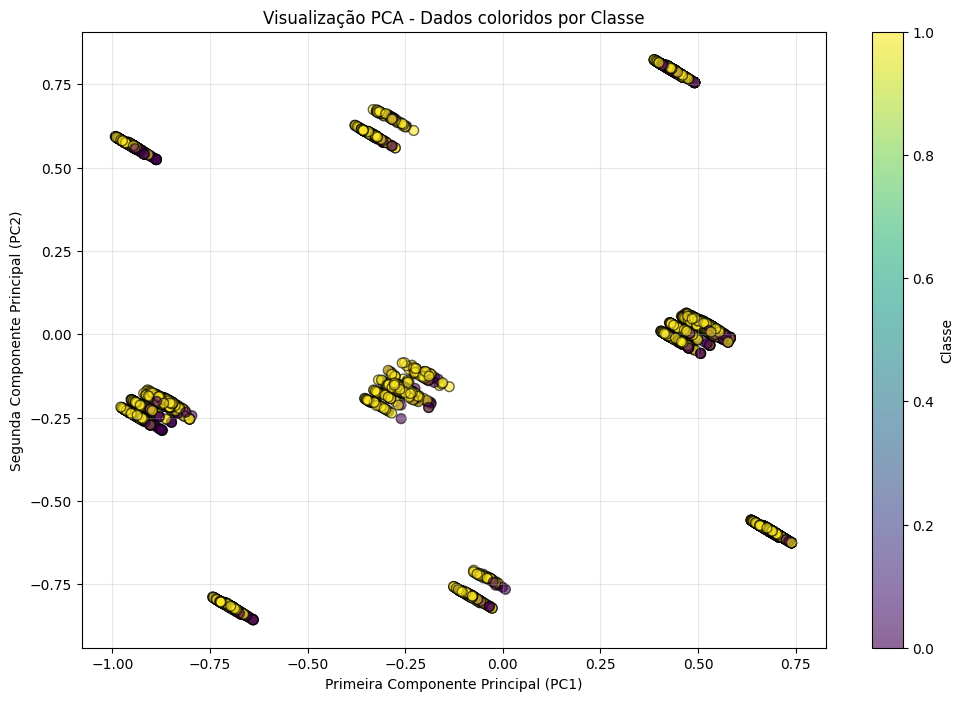

In [9]:
# 7. Criar visualização com scatter plot
# Adicionar a coluna 'classe' do df original ao df_pca_final
df_pca_final['classe'] = df['classe'].values

plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_pca_final['PC1'], df_pca_final['PC2'],
                     c=df_pca_final['classe'],
                     cmap='viridis',
                     alpha=0.6,
                     edgecolors='k',
                     s=50)
plt.colorbar(scatter, label='Classe')
plt.xlabel('Primeira Componente Principal (PC1)')
plt.ylabel('Segunda Componente Principal (PC2)')
plt.title('Visualização PCA - Dados coloridos por Classe')
plt.grid(True, alpha=0.3)
plt.show()

### 8. Adicionar centróides do KMeans no gráfico PCA

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


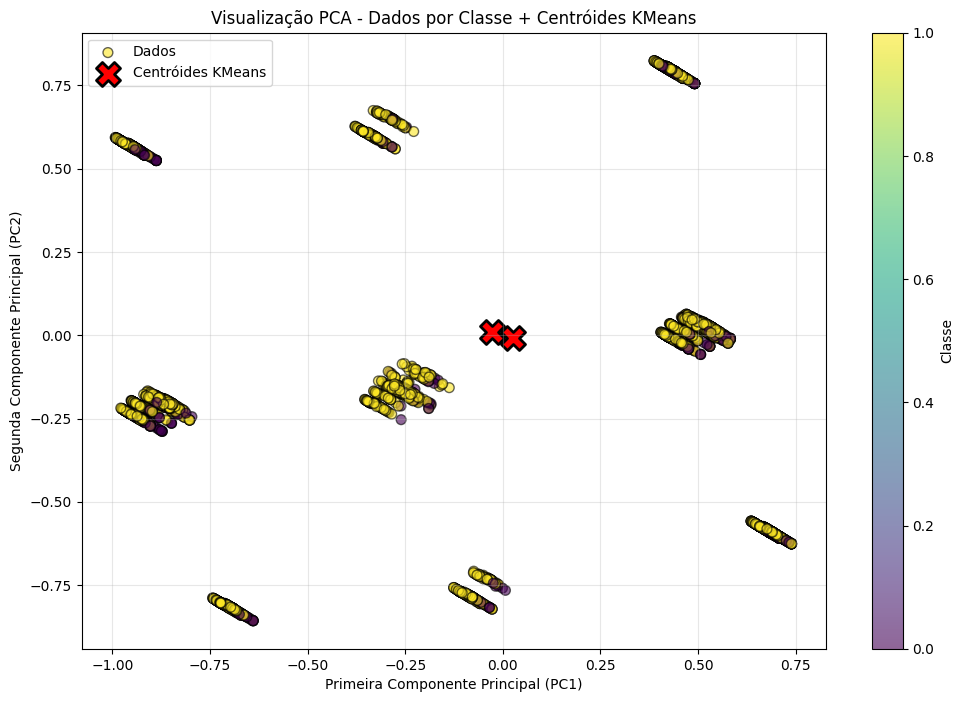

In [10]:
# 8. Transformar centróides do KMeans para o espaço PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)

# Criar visualização completa com dados e centróides
plt.figure(figsize=(12, 8))

# Plotar os dados coloridos por classe
scatter = plt.scatter(df_pca_final['PC1'], df_pca_final['PC2'],
                     c=df_pca_final['classe'],
                     cmap='viridis',
                     alpha=0.6,
                     edgecolors='k',
                     s=50,
                     label='Dados')

# Plotar os centróides do KMeans
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
           c='red',
           marker='X',
           s=300,
           edgecolors='black',
           linewidths=2,
           label='Centróides KMeans')

plt.colorbar(scatter, label='Classe')
plt.xlabel('Primeira Componente Principal (PC1)')
plt.ylabel('Segunda Componente Principal (PC2)')
plt.title('Visualização PCA - Dados por Classe + Centróides KMeans')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Comparação: KMeans + PCA usando apenas variáveis numéricas

[Numéricos] Distribuição dos clusters: [7643 1265]
[Numéricos] Variância explicada: [0.86660512 0.12723974]
[Numéricos] Variância total explicada: 0.9938


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


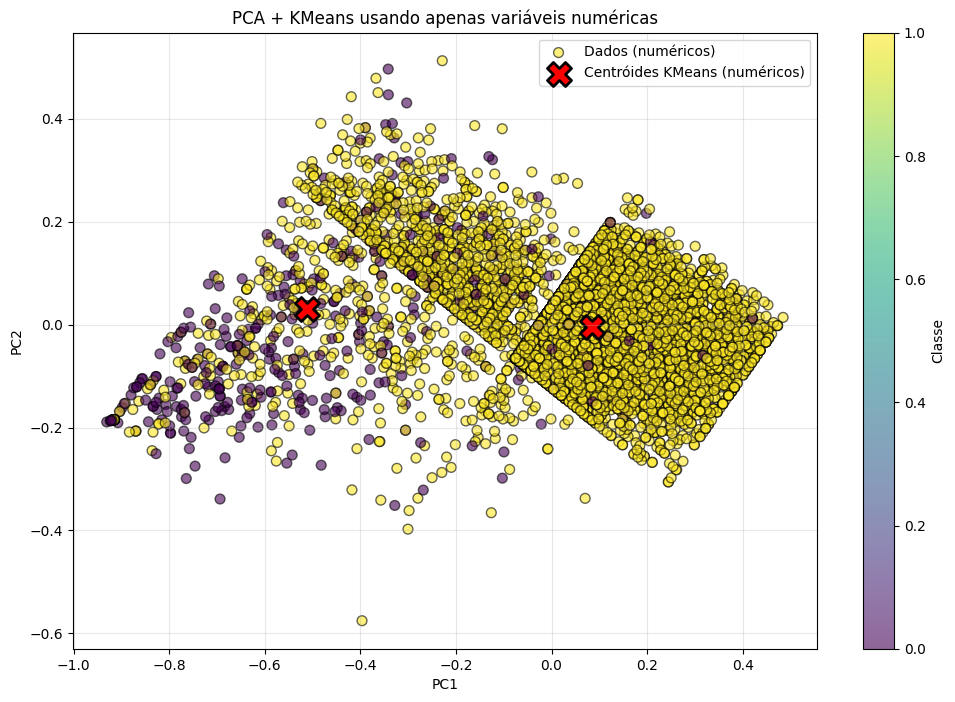

In [11]:
# Pipeline paralelo: apenas dados numéricos
# 5b. KMeans nos dados numéricos
kmeans_num = KMeans(n_clusters=2, random_state=42)
kmeans_labels_num = kmeans_num.fit_predict(df_numericos_processados)

print("[Numéricos] Distribuição dos clusters:", np.bincount(kmeans_labels_num))

# 6b. PCA com 2 componentes nos dados numéricos
pca_num = PCA(n_components=2)
df_pca_num = pca_num.fit_transform(df_numericos_processados)

print("[Numéricos] Variância explicada:", pca_num.explained_variance_ratio_)
print(f"[Numéricos] Variância total explicada: {pca_num.explained_variance_ratio_.sum():.4f}")

# DataFrame com PCs + classe para colorir
df_pca_num_final = pd.DataFrame(df_pca_num, columns=['PC1', 'PC2'])
df_pca_num_final['classe'] = df['classe'].values

# Centróides do KMeans projetados no espaço PCA
centroides_pca_num = pca_num.transform(kmeans_num.cluster_centers_)

# 7b/8b. Visualização dos dados numéricos e centróides
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_pca_num_final['PC1'], df_pca_num_final['PC2'],
                     c=df_pca_num_final['classe'],
                     cmap='viridis',
                     alpha=0.6,
                     edgecolors='k',
                     s=50,
                     label='Dados (numéricos)')

plt.scatter(centroides_pca_num[:, 0], centroides_pca_num[:, 1],
           c='red',
           marker='X',
           s=300,
           edgecolors='black',
           linewidths=2,
           label='Centróides KMeans (numéricos)')

plt.colorbar(scatter, label='Classe')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA + KMeans usando apenas variáveis numéricas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()